# Optional Lab: Know Data Images with Fourier

This optional notebook adds one more way to look at images before classification and defect detection.

So far, an image has been a grid of pixel brightness values. A Fourier transform asks a different question:

**How much of this image is made from slow, broad changes, and how much is made from fast, fine detail?**

That matters because device images often contain repeated edges, textures, scratches, shadows, and small defects. Fourier views can help us notice those patterns before we ask a classifier or defect detector to make decisions.

In this notebook, we will:

- build simple known-pattern images,
- compare their frequency views,
- inspect real device images in frequency space,
- separate low-frequency and high-frequency information,
- connect the idea to later classification and defect-detection notebooks.


## 1. Imports and paths


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from PIL import Image, ImageOps

# Find the notebook folder so imports and dataset paths work from either the
# repository root or the 0_Class_Notebooks folder.
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "0_Class_Notebooks":
    candidate = NOTEBOOK_DIR / "0_Class_Notebooks"
    if candidate.exists():
        NOTEBOOK_DIR = candidate

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from workshop_image_utils import load_image_records

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (9, 5)

DEVICE_ROOT = (NOTEBOOK_DIR.parent / "Device_Images_Nelson").resolve()
IMAGE_SIZE = 224


## 2. Helper functions

These helper functions keep the Fourier math in one place. You do not need to memorize them.

The important ideas are:

- `fft2` converts a 2D image into frequency information.
- `fftshift` moves the slowest changes to the center of the plot.
- `log1p` makes tiny and huge frequency values easier to see in the same picture.


In [2]:
def load_grayscale_image(path, size=IMAGE_SIZE):
    """Load one image as a square grayscale array with values from 0 to 1."""
    with Image.open(path) as image:
        image = ImageOps.fit(image.convert("L"), (size, size), method=Image.Resampling.BICUBIC)
    return np.asarray(image, dtype=float) / 255.0


def fourier_transform(image_2d):
    """Return the centered Fourier transform for a grayscale image."""
    return np.fft.fftshift(np.fft.fft2(image_2d))


def fourier_magnitude_view(image_2d):
    """Return a display-friendly log magnitude image."""
    transformed = fourier_transform(image_2d)
    return np.log1p(np.abs(transformed))


def frequency_radius(size):
    """Make a radius map where 0 is the center and 1 is the farthest corner."""
    y, x = np.indices((size, size))
    center = (size - 1) / 2
    radius = np.sqrt((x - center) ** 2 + (y - center) ** 2)
    return radius / radius.max()


def reconstruct_from_mask(image_2d, mask):
    """Keep only selected frequencies, then transform back to an image."""
    transformed = fourier_transform(image_2d)
    filtered = transformed * mask
    reconstructed = np.fft.ifft2(np.fft.ifftshift(filtered)).real
    return np.clip(reconstructed, 0, 1)


def radial_frequency_profile(image_2d, bins=12):
    """Summarize average Fourier magnitude from low to high frequency bands."""
    magnitude = np.abs(fourier_transform(image_2d))
    radius = frequency_radius(image_2d.shape[0])
    edges = np.linspace(0, 1, bins + 1)
    values = []
    labels = []
    for left, right in zip(edges[:-1], edges[1:]):
        band = (radius >= left) & (radius < right)
        values.append(magnitude[band].mean())
        labels.append(f"{left:.2f}-{right:.2f}")
    return pd.DataFrame({"frequency_band": labels, "average_magnitude": values})


def show_image_and_fourier(images, titles):
    fig, axes = plt.subplots(2, len(images), figsize=(4 * len(images), 7))
    if len(images) == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for col, (image, title) in enumerate(zip(images, titles)):
        axes[0, col].imshow(image, cmap="gray")
        axes[0, col].set_title(title)
        axes[0, col].axis("off")

        axes[1, col].imshow(fourier_magnitude_view(image), cmap="magma")
        axes[1, col].set_title("Fourier magnitude")
        axes[1, col].axis("off")

    plt.tight_layout()
    plt.show()


## 3. Known-pattern images

Before using real device images, let's create simple images where we already know what pattern is present.

Try reading each Fourier view like this:

- smooth image: energy mostly near the center,
- stripe image: strong points or lines in specific directions,
- checker image: repeated high-detail pattern,
- small spot: many frequencies are needed to describe a sharp local change.


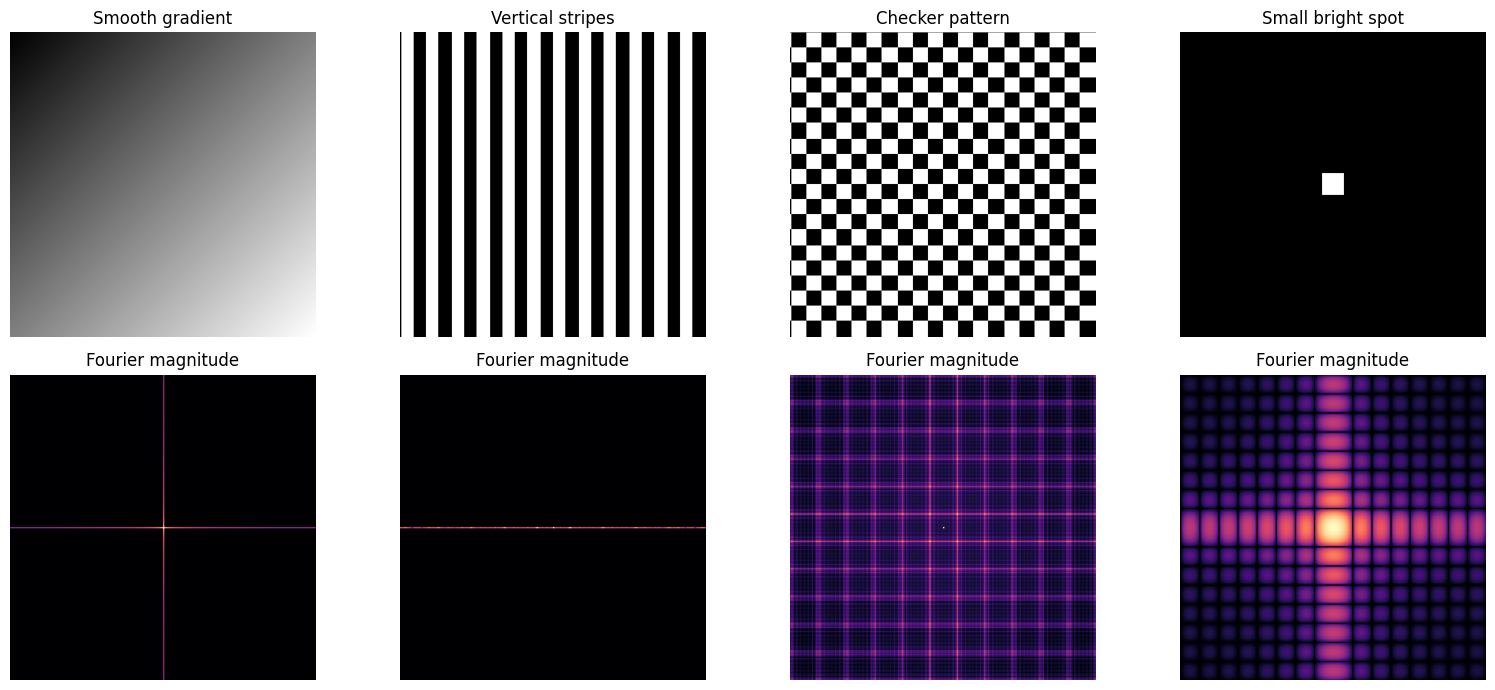

In [3]:
size = IMAGE_SIZE
x = np.linspace(0, 1, size)
y = np.linspace(0, 1, size)
xx, yy = np.meshgrid(x, y)

smooth_gradient = (xx + yy) / 2
vertical_stripes = (np.sin(2 * np.pi * 12 * xx) > 0).astype(float)
checker = ((np.sin(2 * np.pi * 10 * xx) > 0) ^ (np.sin(2 * np.pi * 10 * yy) > 0)).astype(float)
small_spot = np.zeros((size, size), dtype=float)
small_spot[size // 2 - 8:size // 2 + 8, size // 2 - 8:size // 2 + 8] = 1

known_images = [smooth_gradient, vertical_stripes, checker, small_spot]
known_titles = ["Smooth gradient", "Vertical stripes", "Checker pattern", "Small bright spot"]
show_image_and_fourier(known_images, known_titles)


### Student pause

For each known image, answer:

- Which one has the strongest broad, low-frequency structure?
- Which one has the strongest repeated pattern?
- Which one needs high frequencies because it changes suddenly?


## 4. Load real device images

Now we will use the same idea on workshop device images. The code chooses one regular device image and one defect image when both are available.


In [4]:
records = load_image_records(DEVICE_ROOT)
records[["relative_path", "device_type", "damage_status", "is_defect_folder"]].head()


,relative_path,device_type,damage_status,is_defect_folder
0,Defect/1_Defect(1).png,device1,Damaged,True
1,Defect/1_Defect(2).png,device1,Damaged,True
2,Defect/1_Defect(3).png,device1,Damaged,True
3,Defect/1_Defect(4).png,device1,Damaged,True
4,Defect/1_Defect.png,device1,Damaged,True


Regular image: device 2\1.png
Defect image: Defect\1_Defect(1).png


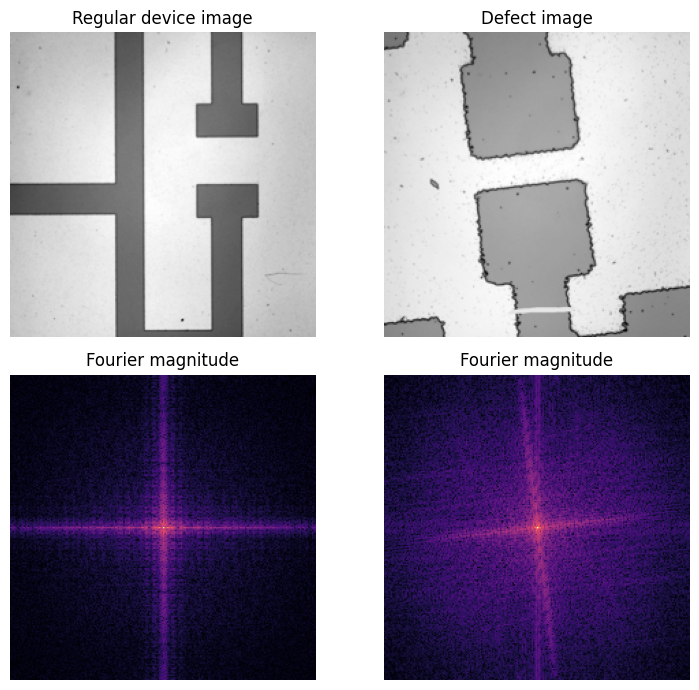

In [5]:
regular_candidates = records[records["is_standard_device_image"]].reset_index(drop=True)
defect_candidates = records[records["is_defect_folder"]].reset_index(drop=True)

if regular_candidates.empty:
    raise ValueError("No regular device images were found.")

regular_path = Path(regular_candidates.iloc[0]["filepath"])
defect_path = Path(defect_candidates.iloc[0]["filepath"]) if not defect_candidates.empty else regular_path

regular_image = load_grayscale_image(regular_path)
defect_image = load_grayscale_image(defect_path)

print("Regular image:", regular_path.relative_to(DEVICE_ROOT))
print("Defect image:", defect_path.relative_to(DEVICE_ROOT))

show_image_and_fourier(
    [regular_image, defect_image],
    ["Regular device image", "Defect image"],
)


## 5. Low frequencies and high frequencies

Low frequencies describe broad structure: overall shape, lighting, large shadows, and slow changes.

High frequencies describe quick changes: edges, small scratches, texture, noise, and other fine detail.

A classifier or defect detector might use either one, so it is worth asking which part of the image carries the useful signal.


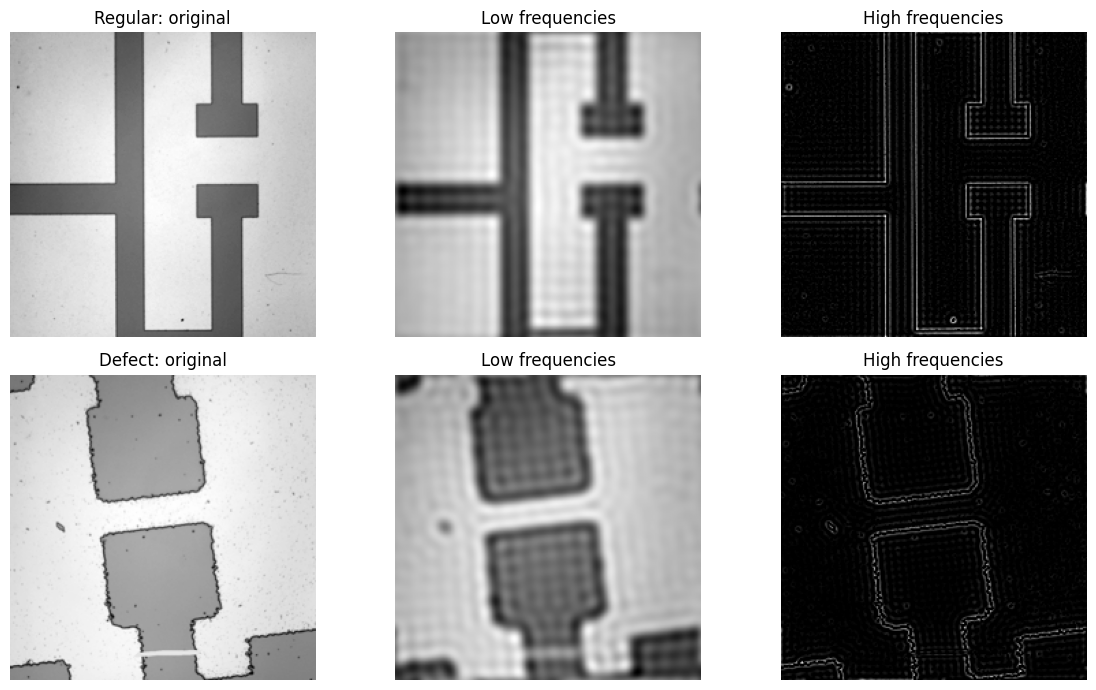

In [6]:
radius = frequency_radius(IMAGE_SIZE)
LOW_CUTOFF = 0.12
HIGH_CUTOFF = 0.28

low_pass_mask = radius <= LOW_CUTOFF
high_pass_mask = radius >= HIGH_CUTOFF

low_regular = reconstruct_from_mask(regular_image, low_pass_mask)
high_regular = reconstruct_from_mask(regular_image, high_pass_mask)
low_defect = reconstruct_from_mask(defect_image, low_pass_mask)
high_defect = reconstruct_from_mask(defect_image, high_pass_mask)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for row, (label, original, low_view, high_view) in enumerate([
    ("Regular", regular_image, low_regular, high_regular),
    ("Defect", defect_image, low_defect, high_defect),
]):
    for ax, image, title in zip(
        axes[row],
        [original, low_view, high_view],
        [f"{label}: original", "Low frequencies", "High frequencies"],
    ):
        ax.imshow(image, cmap="gray")
        ax.set_title(title)
        ax.axis("off")

plt.tight_layout()
plt.show()


### Change point

Try changing `LOW_CUTOFF` and `HIGH_CUTOFF`, then rerun the cell above.

Questions to ask:

- When does the low-frequency image become too blurry to identify the device?
- When does the high-frequency image start showing mostly noise?
- Do defects look more visible in the original image, the low-frequency image, or the high-frequency image?


## 6. Fourier denoising

Fourier filtering can also remove some kinds of noise. The basic idea is:

1. Add noise to an image so we know what the clean answer should look like.
2. Transform the noisy image into frequency space.
3. Choose a mask for which frequency values to keep.
4. Transform back to pixels.

We compare two mask choices here:

- A **radius mask** keeps frequencies near the center of the Fourier view.
- An **intensity mask** keeps the strongest Fourier values, wherever they appear.
- A **toggle mask** lets you apply the radius mask, the intensity mask, or both at the same time.

This works best when the noise appears as scattered, high-frequency speckles. It can blur useful sharp edges too, so the cutoff is a decision, not magic.

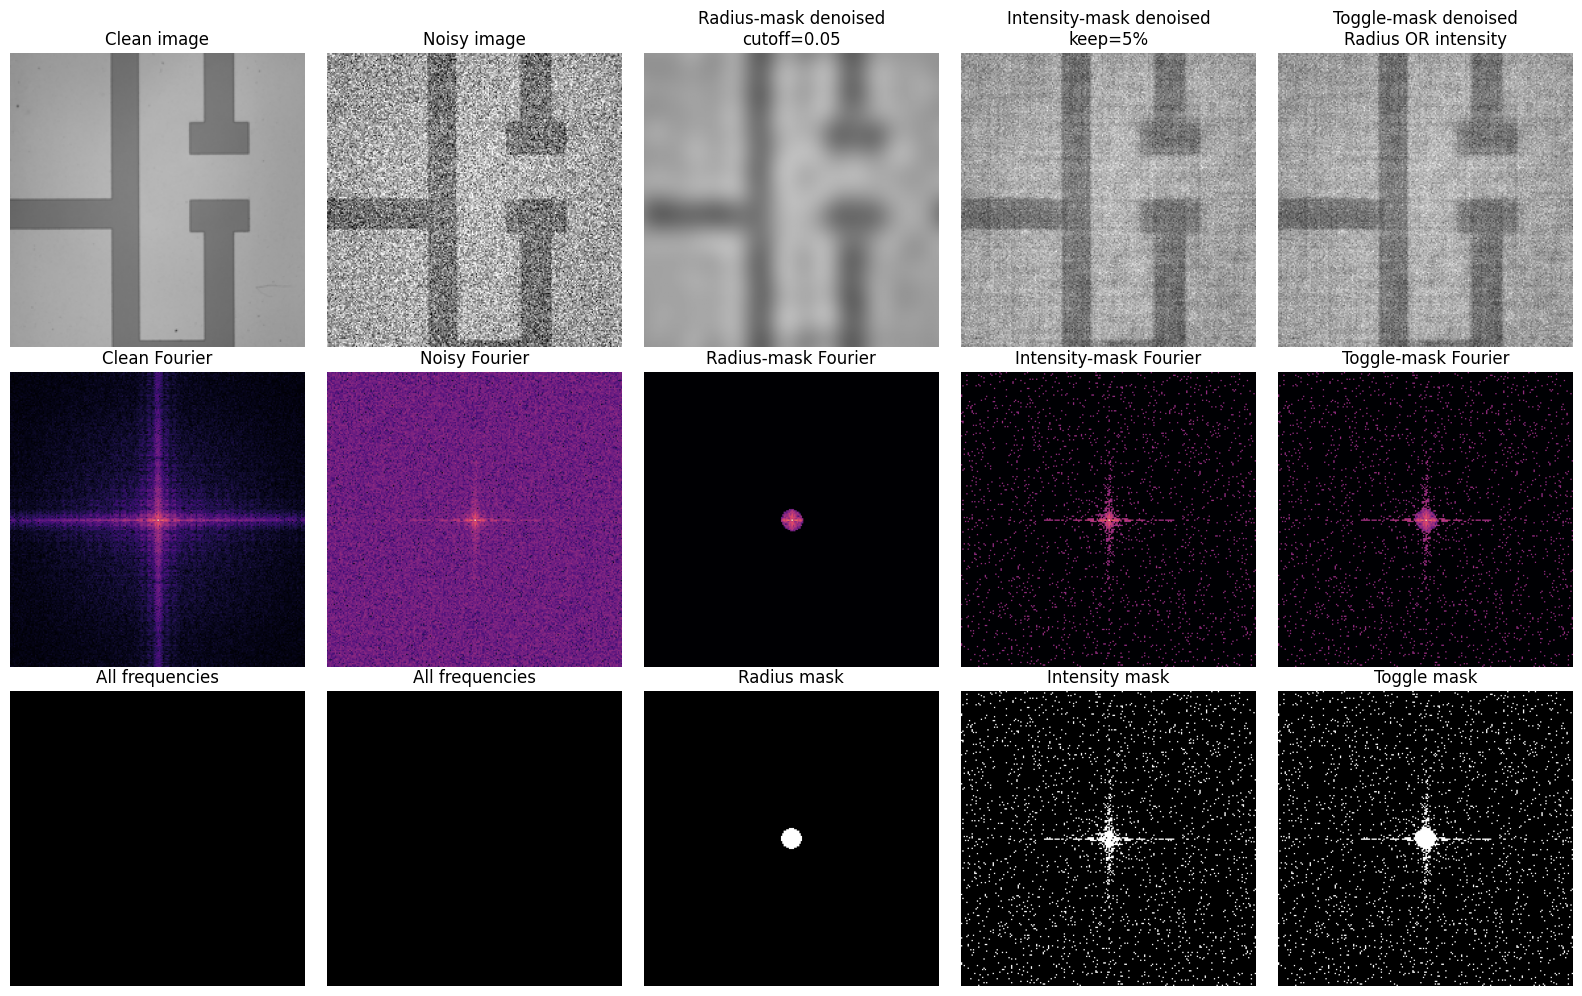

,image,MSE vs clean,PSNR vs clean,fraction kept
0,Noisy image,0.031156,15.064540,1.000000
1,Radius-mask denoised,0.001600,27.958957,0.003827
2,Intensity-mask denoised,0.006414,21.928402,0.050004
3,Toggle-mask denoised (Radius OR intensity),0.006369,21.959173,0.051020


In [19]:
rng = np.random.default_rng(42)
noise_strength = 0.18
RADIUS_CUTOFF = 0.05
INTENSITY_KEEP_FRACTION = 0.05
USE_RADIUS_MASK = True
USE_INTENSITY_MASK = True
COMBINE_MASKS_WITH = "or"  # Choose "and" for stricter filtering or "or" for looser filtering.

clean_image = regular_image
noisy_image = np.clip(clean_image + rng.normal(0, noise_strength, clean_image.shape), 0, 1)

noisy_fourier = fourier_transform(noisy_image)
noisy_magnitude = np.abs(noisy_fourier)

# Mask option 1: keep a circle of low and middle frequencies around the center.
radius = frequency_radius(clean_image.shape[0])
radius_mask = radius <= RADIUS_CUTOFF

# Mask option 2: keep the strongest Fourier values, regardless of location.
intensity_threshold = np.quantile(noisy_magnitude, 1 - INTENSITY_KEEP_FRACTION)
intensity_mask = noisy_magnitude >= intensity_threshold

radius_denoised = reconstruct_from_mask(noisy_image, radius_mask)
intensity_denoised = reconstruct_from_mask(noisy_image, intensity_mask)

if USE_RADIUS_MASK and USE_INTENSITY_MASK:
    if COMBINE_MASKS_WITH == "and":
        toggle_mask = radius_mask & intensity_mask
        toggle_label = "Radius AND intensity"
    elif COMBINE_MASKS_WITH == "or":
        toggle_mask = radius_mask | intensity_mask
        toggle_label = "Radius OR intensity"
    else:
        raise ValueError('COMBINE_MASKS_WITH must be "and" or "or"')
elif USE_RADIUS_MASK:
    toggle_mask = radius_mask
    toggle_label = "Radius only"
elif USE_INTENSITY_MASK:
    toggle_mask = intensity_mask
    toggle_label = "Intensity only"
else:
    toggle_mask = np.ones_like(radius_mask, dtype=bool)
    toggle_label = "No mask"

toggle_denoised = reconstruct_from_mask(noisy_image, toggle_mask)

def mean_squared_error(reference, candidate):
    return np.mean((reference - candidate) ** 2)


def psnr(reference, candidate):
    mse = mean_squared_error(reference, candidate)
    if mse == 0:
        return np.inf
    return 20 * np.log10(1.0 / np.sqrt(mse))

fig, axes = plt.subplots(3, 5, figsize=(16, 10))

for ax, image, title in zip(
    axes[0],
    [clean_image, noisy_image, radius_denoised, intensity_denoised, toggle_denoised],
    [
        "Clean image",
        "Noisy image",
        f"Radius-mask denoised\ncutoff={RADIUS_CUTOFF}",
        f"Intensity-mask denoised\nkeep={INTENSITY_KEEP_FRACTION:.0%}",
        f"Toggle-mask denoised\n{toggle_label}",
    ],
):
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

for ax, image, title in zip(
    axes[1],
    [clean_image, noisy_image, radius_denoised, intensity_denoised, toggle_denoised],
    ["Clean Fourier", "Noisy Fourier", "Radius-mask Fourier", "Intensity-mask Fourier", "Toggle-mask Fourier"],
):
    ax.imshow(fourier_magnitude_view(image), cmap="magma")
    ax.set_title(title)
    ax.axis("off")

for ax, mask, title in zip(
    axes[2],
    [np.ones_like(radius_mask), np.ones_like(radius_mask), radius_mask, intensity_mask, toggle_mask],
    ["All frequencies", "All frequencies", "Radius mask", "Intensity mask", "Toggle mask"],
):
    ax.imshow(mask, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

scores = pd.DataFrame({
    "image": ["Noisy image", "Radius-mask denoised", "Intensity-mask denoised", f"Toggle-mask denoised ({toggle_label})"],
    "MSE vs clean": [
        mean_squared_error(clean_image, noisy_image),
        mean_squared_error(clean_image, radius_denoised),
        mean_squared_error(clean_image, intensity_denoised),
        mean_squared_error(clean_image, toggle_denoised),
    ],
    "PSNR vs clean": [
        psnr(clean_image, noisy_image),
        psnr(clean_image, radius_denoised),
        psnr(clean_image, intensity_denoised),
        psnr(clean_image, toggle_denoised),
    ],
    "fraction kept": [
        1.0,
        radius_mask.mean(),
        intensity_mask.mean(),
        toggle_mask.mean(),
    ],
})

scores

### Change point

Try changing `noise_strength`, `RADIUS_CUTOFF`, `INTENSITY_KEEP_FRACTION`, `USE_RADIUS_MASK`, `USE_INTENSITY_MASK`, and `COMBINE_MASKS_WITH`, then rerun the cell above.

- Which mask removes the most visible speckle?
- Is `"and"` or `"or"` better when both masks are turned on?
- At what point does the image become too blurry?
- Does the intensity mask keep any frequency points outside the radius mask?
- Does the PSNR score agree with what your eyes prefer?

## 7. Frequency profiles

A Fourier image is still an image. Sometimes we want a smaller table of numbers that a model can use.

One simple approach is to divide the Fourier view into rings from the center outward and calculate the average energy in each ring. This creates a frequency profile.


In [8]:
regular_profile = radial_frequency_profile(regular_image, bins=14)
defect_profile = radial_frequency_profile(defect_image, bins=14)
profile = regular_profile.merge(defect_profile, on="frequency_band", suffixes=("_regular", "_defect"))
profile


,frequency_band,average_magnitude_regular,average_magnitude_defect
0,0.00-0.07,191.294439,235.626513
1,0.07-0.14,21.526359,37.718915
2,0.14-0.21,9.351750,21.902944
3,0.21-0.29,5.067943,14.998594
4,0.29-0.36,3.621479,10.760570
5,0.36-0.43,2.827307,8.476386
6,0.43-0.50,2.042699,6.730985
7,0.50-0.57,1.505163,5.194244
8,0.57-0.64,1.162686,3.890667
9,0.64-0.71,1.009132,2.971808


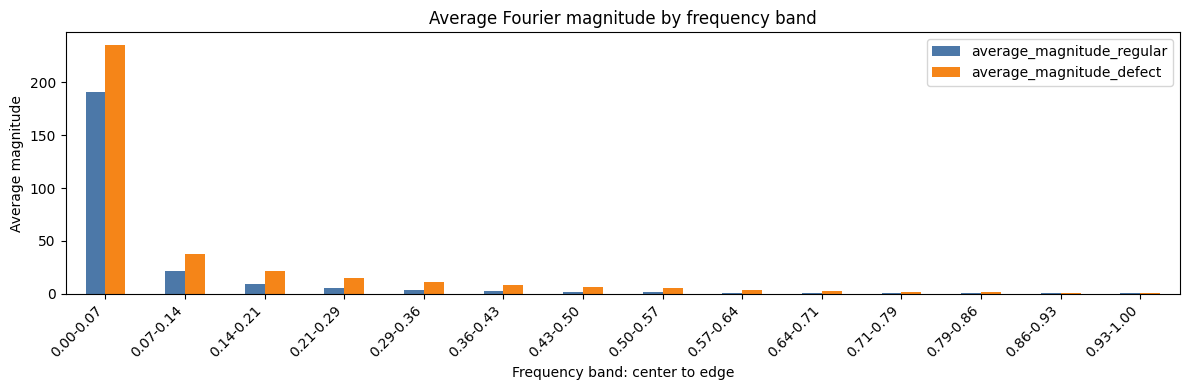

In [9]:
profile_plot = profile.set_index("frequency_band")
ax = profile_plot.plot(kind="bar", figsize=(12, 4), color=["#4c78a8", "#f58518"])
ax.set_title("Average Fourier magnitude by frequency band")
ax.set_xlabel("Frequency band: center to edge")
ax.set_ylabel("Average magnitude")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 8. Bridge to classification and defect detection

This notebook does not train a model. It prepares the idea.

Later notebooks use Fourier features in two ways:

- **Classification:** represent each image by frequency-band features, then train a model to predict a label.
- **Defect detection:** compare frequency patterns from a test image against clean reference images.

The important decision question is not "Is Fourier always better?" It is:

**Does frequency information reveal a useful pattern that raw pixels, color, or human inspection might miss?**


## 9. Reflection

Write a short answer before moving on:

1. What kind of image detail seems to live near the center of the Fourier view?
2. What kind of image detail seems to live farther away from the center?
3. If a model focused on high frequencies, what useful signal might it find?
4. What misleading signal might it find instead?
